In [2]:
import pandas as pd
import xarray as xr
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/all_numerical_vars.csv")

In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. START FROM stats_df
# --------------------------------------------------

# Ensure we are working on a copy
df = stats_df.copy()

# --------------------------------------------------
# 2. SELECT NUMERIC VARIABLES ONLY
#    (PCA is ONLY for continuous variables)
# --------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number])

# Optional: drop identifiers if they slipped in
# (station is numeric but should not be in PCA)
#if "station" in numeric_df.columns:
#    numeric_df = numeric_df.drop(columns=["station"])


In [8]:
metadata_cols = ["station", "lat", "lon", "longitude", "latitude", "block_time",  "year", "residual_is_deviant", "residual", "tide"]

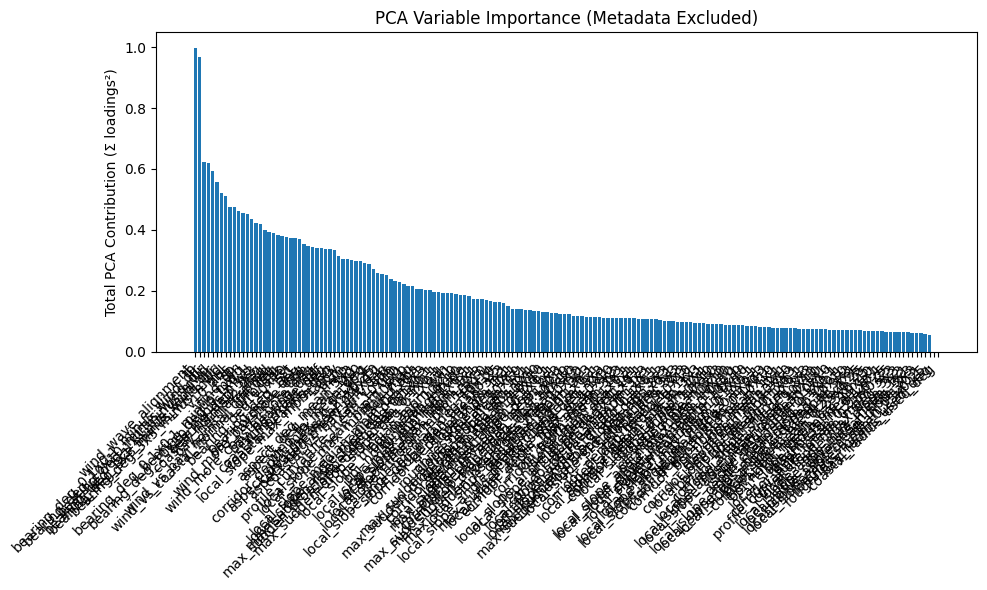

Variables used in PCA: 172
Retained PCs: 33
Cumulative variance explained: 0.953


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. DEFINE METADATA COLUMNS (EXCLUDED FROM PCA)
# --------------------------------------------------

metadata_cols = [c for c in metadata_cols if c in stats_df.columns]

# --------------------------------------------------
# 2. SELECT PCA VARIABLES ONLY
# --------------------------------------------------

pca_df = numeric_df.drop(columns=metadata_cols)

# Keep numeric variables only
pca_df = pca_df.select_dtypes(include=[np.number])

# Drop rows with missing values
pca_df = pca_df.dropna(axis=0)

# --------------------------------------------------
# 3. STANDARDIZE
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# --------------------------------------------------
# 4. FIT FULL PCA
# --------------------------------------------------

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# --------------------------------------------------
# 5. EXPLAINED VARIANCE TABLE
# --------------------------------------------------

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_full.explained_variance_ratio_
        ),
    }
)

# --------------------------------------------------
# 6. SELECT COMPONENTS (95% VARIANCE)
# --------------------------------------------------

n_components = int(
    explained_variance.loc[
        explained_variance["cumulative_explained_variance"] >= 0.95,
        "component",
    ].iloc[0]
)

# --------------------------------------------------
# 7. REFIT PCA WITH REDUCED DIMENSION
# --------------------------------------------------

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --------------------------------------------------
# 8. PCA SCORES
# --------------------------------------------------

pca_columns = [f"PC{i+1}" for i in range(n_components)]
pca_scores_df = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=pca_df.index,
)

# --------------------------------------------------
# 9. LOADINGS
# --------------------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_df.columns,
    columns=pca_columns,
)

# --------------------------------------------------
# 10. VARIABLE IMPORTANCE (Σ loadings²)
# --------------------------------------------------

variable_importance = (loadings ** 2).sum(axis=1)
variable_importance = variable_importance.sort_values(ascending=False)

# --------------------------------------------------
# 11. PLOT: MOST → LEAST IMPORTANT VARIABLES
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(variable_importance.index, variable_importance.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total PCA Contribution (Σ loadings²)")
plt.title("PCA Variable Importance (Metadata Excluded)")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. OPTIONAL: MERGE METADATA BACK
# --------------------------------------------------

final_pca_df = pd.concat(
    [
        numeric_df.loc[pca_scores_df.index, metadata_cols],
        pca_scores_df,
    ],
    axis=1,
)

# --------------------------------------------------
# 13. SUMMARY
# --------------------------------------------------

print(f"Variables used in PCA: {pca_df.shape[1]}")
print(f"Retained PCs: {n_components}")
print(
    f"Cumulative variance explained: "
    f"{explained_variance.loc[n_components-1, 'cumulative_explained_variance']:.3f}"
)


In [29]:
selected_vars = variable_importance.cumsum()
selected_vars = selected_vars[selected_vars <= 0.6 * selected_vars.iloc[-1]].index

In [40]:
hoi = selected_vars.to_list()
hoi.append("station")
hoi.append("swh")
hoi.append("lat")
hoi.append("lon")
hoi.append("lon")
selected_df = numeric_df[hoi]
selected_df["time"] = df.extract_time

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_34384/1044479975.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["time"] = df.extract_time


In [41]:
selected_df.to_csv("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/station_pca_variables.csv")